<a href="https://colab.research.google.com/github/JesseOrtega01/streamlit1/blob/main/Solucion_Reto_SC_63_JesseRobertoPe%C3%B1aOrtega.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto bank marketing

Hecho por: Jesse Roberto Peña Ortega

4.- 4.	Incluye las librerías que consideres adecuadas y carga los datos del archivo en una variable llamada “data”

In [133]:
import pandas as pd

data=pd.read_csv('/content/bank_marketing.csv')
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,self-employed,married,tertiary,no,2666,no,no,cellular,10,nov,318,2,97,6,success,yes
1,29,unemployed,single,unknown,no,1584,no,no,cellular,6,sep,245,1,-1,0,unknown,yes
2,41,blue-collar,married,secondary,no,2152,yes,no,cellular,17,nov,369,1,-1,0,unknown,no
3,50,blue-collar,married,secondary,no,84,yes,no,cellular,17,jul,18,8,-1,0,unknown,no
4,40,admin.,married,secondary,no,0,no,no,cellular,28,jul,496,2,182,11,success,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,42,blue-collar,married,secondary,no,314,yes,yes,unknown,16,may,269,2,-1,0,unknown,no
8996,32,blue-collar,married,secondary,no,491,yes,no,unknown,8,may,223,2,-1,0,unknown,no
8997,44,services,single,secondary,no,2886,no,no,unknown,20,jun,31,1,-1,0,unknown,no
8998,57,services,married,primary,no,491,yes,no,cellular,15,apr,1217,3,-1,0,unknown,yes


5.Obtener la información de dicha base de datos que incluya el número de registros, el total de variables, el tipo de cada variable, la cantidad de datos perdidos de cada variable en caso de que existan


In [134]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB


In [135]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

6.	Transforma las variables categóricas de manera que puedan ser tratadas numéricamente. Justifica si utilizas LabelEncoder o OneHotEcoder


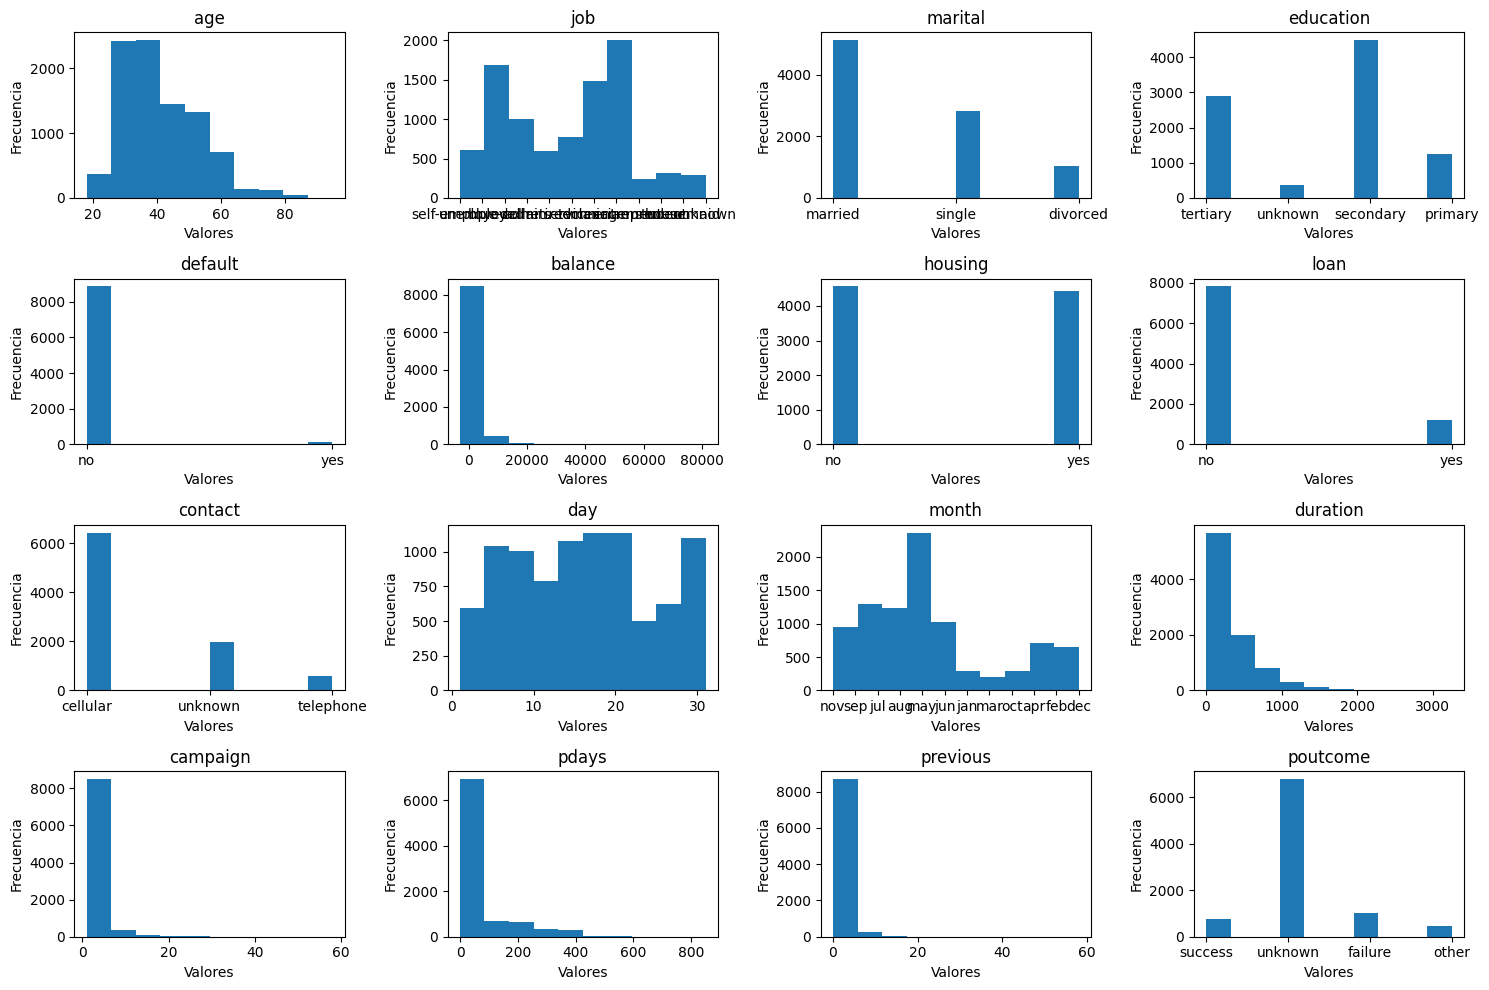

In [136]:
import matplotlib.pyplot as plt

fig,axs=plt.subplots(4,4,figsize=(15,10))

for i in range (4):
  for j in range (4):
    axs[i,j].hist(data[data.columns[i*4+j]])
    axs[i,j].set_title(data.columns[i*4+j])
    axs[i,j].set_xlabel('Valores')
    axs[i,j].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


In [137]:
data['education'].unique()

array(['tertiary', 'unknown', 'secondary', 'primary'], dtype=object)

In [138]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

labelcol=['default','housing','loan']

for col in labelcol:
  label=LabelEncoder()
  data[col]=label.fit_transform(data[col])

educationmapping={'unknown':0,'primary':1,'secondary':2,'tertiary':3}
data['education']=data['education'].map(educationmapping)

hotcol=['job', 'marital', 'contact', 'month', 'poutcome']
onehot=OneHotEncoder(handle_unknown='ignore')


preprocessor=ColumnTransformer(transformers=[('onehot',onehot,hotcol)],remainder='passthrough')
dataT=preprocessor.fit_transform(data)
newdata=pd.DataFrame(dataT,columns=preprocessor.get_feature_names_out())

newdata

,onehot__job_admin.,onehot__job_blue-collar,onehot__job_entrepreneur,onehot__job_housemaid,onehot__job_management,onehot__job_retired,onehot__job_self-employed,onehot__job_services,onehot__job_student,onehot__job_technician,...,remainder__default,remainder__balance,remainder__housing,remainder__loan,remainder__day,remainder__duration,remainder__campaign,remainder__pdays,remainder__previous,remainder__y
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,2666,0,0,10,318,2,97,6,yes
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1584,0,0,6,245,1,-1,0,yes
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,2152,1,0,17,369,1,-1,0,no
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,84,1,0,17,18,8,-1,0,no
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,28,496,2,182,11,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,314,1,1,16,269,2,-1,0,no
8996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,491,1,0,8,223,2,-1,0,no
8997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,2886,0,0,20,31,1,-1,0,no
8998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,491,1,0,15,1217,3,-1,0,yes


In [139]:
newdata.columns

Index(['onehot__job_admin.', 'onehot__job_blue-collar',
       'onehot__job_entrepreneur', 'onehot__job_housemaid',
       'onehot__job_management', 'onehot__job_retired',
       'onehot__job_self-employed', 'onehot__job_services',
       'onehot__job_student', 'onehot__job_technician',
       'onehot__job_unemployed', 'onehot__job_unknown',
       'onehot__marital_divorced', 'onehot__marital_married',
       'onehot__marital_single', 'onehot__contact_cellular',
       'onehot__contact_telephone', 'onehot__contact_unknown',
       'onehot__month_apr', 'onehot__month_aug', 'onehot__month_dec',
       'onehot__month_feb', 'onehot__month_jan', 'onehot__month_jul',
       'onehot__month_jun', 'onehot__month_mar', 'onehot__month_may',
       'onehot__month_nov', 'onehot__month_oct', 'onehot__month_sep',
       'onehot__poutcome_failure', 'onehot__poutcome_other',
       'onehot__poutcome_success', 'onehot__poutcome_unknown',
       'remainder__age', 'remainder__education', 'remainder__defau

In [140]:
newdata[['remainder__pdays','remainder__campaign','remainder__duration']]

,remainder__pdays,remainder__campaign,remainder__duration
0,97,2,318
1,-1,1,245
2,-1,1,369
3,-1,8,18
4,182,2,496
...,...,...,...
8995,-1,2,269
8996,-1,2,223
8997,-1,1,31
8998,-1,3,1217


7.	Transforma las variables numéricas en los casos que se tenga algún tipo de sesgo

In [141]:
newdata[['remainder__pdays','remainder__campaign','remainder__duration']].describe()

,remainder__pdays,remainder__campaign,remainder__duration
count,9000,9000,9000
unique,437,34,1327
top,-1,1,150
freq,6781,3814,34


In [142]:
newdata[['remainder__pdays','remainder__campaign','remainder__duration']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   remainder__pdays     9000 non-null   object
 1   remainder__campaign  9000 non-null   object
 2   remainder__duration  9000 non-null   object
dtypes: object(3)
memory usage: 211.1+ KB


In [143]:
newdata[['remainder__pdays','remainder__campaign','remainder__duration']]=newdata[['remainder__pdays','remainder__campaign','remainder__duration']].astype('float')


In [144]:
newdata[['remainder__pdays','remainder__campaign','remainder__duration']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   remainder__pdays     9000 non-null   float64
 1   remainder__campaign  9000 non-null   float64
 2   remainder__duration  9000 non-null   float64
dtypes: float64(3)
memory usage: 211.1 KB


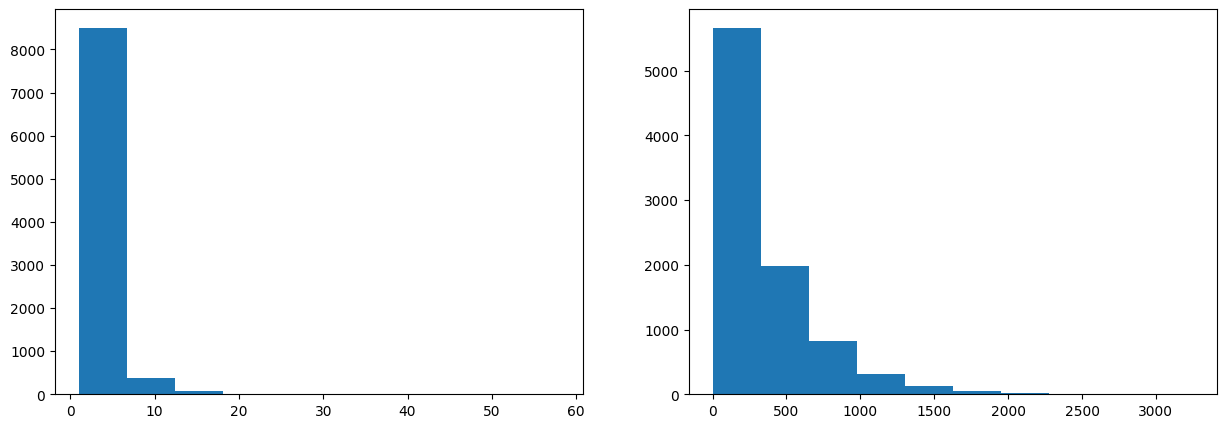

In [145]:
fig,axs=plt.subplots(1,2,figsize=(15,5))

axs[0].hist(data['campaign'], bins=10)
axs[1].hist(data['duration'], bins=10)

plt.show()

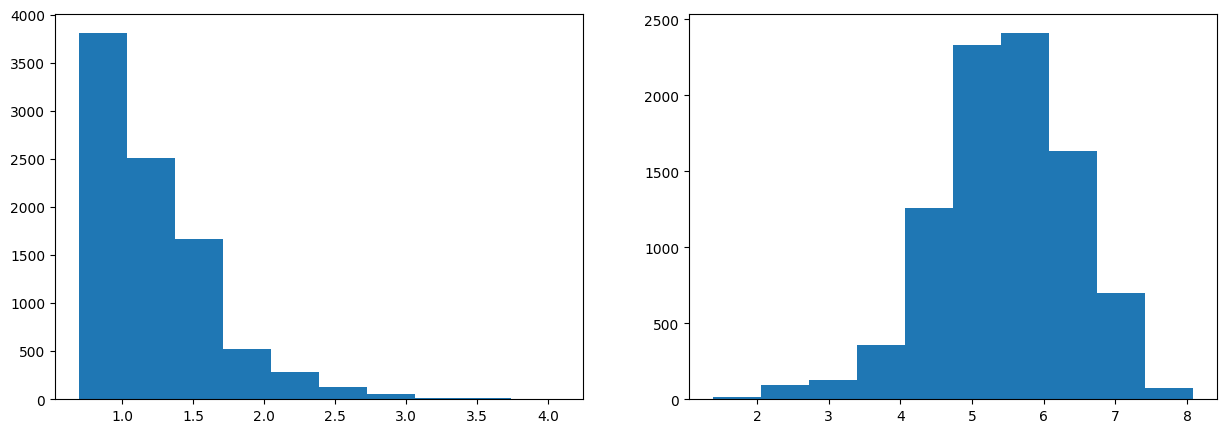

In [146]:
import numpy as np

def log_transform(data):
  return np.log(data+1)

newdata['remainder__campaign']=log_transform(newdata['remainder__campaign'])

newdata['remainder__duration']=log_transform(newdata['remainder__duration'])

fig,axs=plt.subplots(1,2,figsize=(15,5))

axs[0].hist(newdata['remainder__campaign'], bins=10)
axs[1].hist(newdata['remainder__duration'], bins=10)

plt.show()

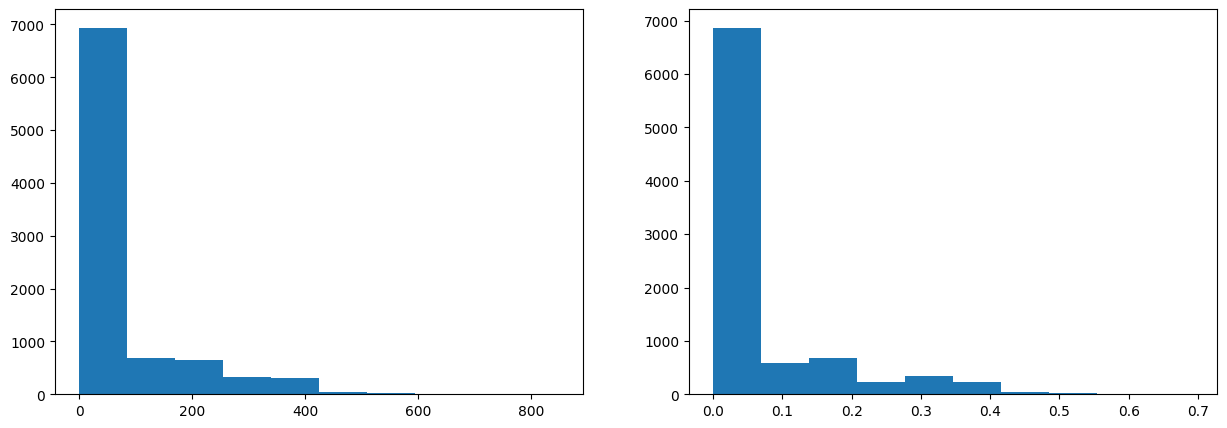

In [147]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

newdata['remainder__pdays']=scaler.fit_transform(newdata[['remainder__pdays']])


newdata['remainder__pdays']=log_transform(newdata['remainder__pdays'])

fig,axs=plt.subplots(1,2,figsize=(15,5))

axs[0].hist(data['pdays'], bins=10)
axs[1].hist(newdata['remainder__pdays'], bins=10)

plt.show()


8.	Considera la variable “y” como la variable de salida y el resto de las variables como las variables de entrada.

In [148]:
x=newdata.drop('remainder__y',axis=1)
y=newdata['remainder__y']


9.-Particiona los datos en los conjuntos de entrenamiento, validación y prueba en 60%, 20% y 20%, respectivamente.

In [149]:
from sklearn.model_selection import train_test_split

x_train_v,x_test,y_train_v, y_test=train_test_split(x,y,test_size=40)
a=9000*.2
b=a/(9000*.6)
print(b)
x_train,x_val,y_train,y_val=train_test_split(x_train_v,y_train_v, test_size=b)


0.3333333333333333


10.	Aplica el modelo Regresión Logística en el conjunto de entrenamiento. Valida el modelo con las predicciones del conjunto de validación y su matriz de confusión. Ajusta los parámetros del modelo hasta obtener tu mejor resultado.

In [150]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf=LogisticRegression(C=1.0,solver='newton-cg')

modelo_RL=clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

score=accuracy_score(y_test,y_pred)
print('accuracy en test: ', score)


print(classification_report(y_test,y_pred))

y_pred_val=modelo_RL.predict(x_val)
print(confusion_matrix(y_val,y_pred_val))


accuracy:  0.8
              precision    recall  f1-score   support

          no       0.81      0.88      0.85        25
         yes       0.77      0.67      0.71        15

    accuracy                           0.80        40
   macro avg       0.79      0.77      0.78        40
weighted avg       0.80      0.80      0.80        40

[[1502  253]
 [ 261  971]]


In [151]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'newton-cg', 'saga'],
    'class_weight': [None, 'balanced']
}


grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score en validación cruzada:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_val = best_model.predict(x_val)

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val))


Mejores parámetros: {'C': 10, 'class_weight': 'balanced', 'solver': 'liblinear'}
Mejor score en validación cruzada: 0.8280616471478733
[[1440  315]
 [ 202 1030]]
              precision    recall  f1-score   support

          no       0.88      0.82      0.85      1755
         yes       0.77      0.84      0.80      1232

    accuracy                           0.83      2987
   macro avg       0.82      0.83      0.82      2987
weighted avg       0.83      0.83      0.83      2987



11.	Aplica el modelo Red Neuronal en el conjunto de entrenamiento. Valida el modelo con las predicciones del conjunto de validación y su matriz de confusión. Ajusta los parámetros del modelo hasta obtener tu mejor modelo, entre ellos el número de neuronas y capas ocultas.

In [153]:
from sklearn.neural_network import MLPClassifier

modelo_NN=MLPClassifier(hidden_layer_sizes=(15,4),max_iter=700)

modelo_NN.fit(x_train,y_train)

print('train score : ',modelo_NN.score(x_train_v,y_train_v))

nn_y_pred=modelo_NN.predict(x_test)

print("Accuracy en test:", accuracy_score(y_test, nn_y_pred))

print(classification_report(y_test, nn_y_pred))

print(confusion_matrix(y_test, nn_y_pred))

train score :  0.7858258928571429
Accuracy en test: 0.825
              precision    recall  f1-score   support

          no       0.82      0.92      0.87        25
         yes       0.83      0.67      0.74        15

    accuracy                           0.82        40
   macro avg       0.83      0.79      0.80        40
weighted avg       0.83      0.82      0.82        40

[[23  2]
 [ 5 10]]


12.	Selecciona el mejor modelo encontrado en los incisos anteriores y utiliza el conjunto de prueba para obtener el desempeño final del modelo y su matriz de confusión.

el modelo que mejor se desempeño fue regresion logistica

In [164]:
y_test_LR_result=best_model.predict(x_test)
score_LR=accuracy_score(y_test,y_test_LR_result)
print('score del test: ',score_LR)
print(confusion_matrix(y_test, y_test_LR_result))
print(classification_report(y_test, y_test_LR_result))

score del test:  0.875
[[22  3]
 [ 2 13]]
              precision    recall  f1-score   support

          no       0.92      0.88      0.90        25
         yes       0.81      0.87      0.84        15

    accuracy                           0.88        40
   macro avg       0.86      0.87      0.87        40
weighted avg       0.88      0.88      0.88        40



Conclusiones:
el modelo tiene mayor precision al predecir un no (representa personas que no compraran el plan de inversion), al tener esto en consideracion se puede concluir que no se perdera tanto tiempo en hacer promocion a este segmento de la poblacion ya que sera rechazado el 92% del publico que no contratara, por otro lado al elegir el publico obejetivo el modelo predice el 81% de los clientes adecuados
